# PCA — Handwritten Digit Recognition 

**Goal:** Implement PCA end-to-end on the classic Digits dataset — reduce the 64 pixel features down to a much smaller set of principal components, and compare a classifier trained on the raw pixels vs. one trained on the PCA-reduced features. Along the way, visualize what PCA is actually doing to image data (variance captured, 2D projection, and reconstruction quality at different numbers of components).

**Dataset:** `sklearn.datasets.load_digits` — 1,797 samples of handwritten digits (0-9), each an 8×8 grayscale image (64 pixel features, pixel intensity 0-16).

**Structure of this notebook :**
1. Setup & Data Understanding (EDA)
2. Baseline Model — no PCA
3. Applying PCA (standardize, fit, explained variance, choose k)
4. Model on PCA-reduced data + Visualization (2D projection + image reconstruction)
5. Insights & Comparison


## 1. Setup & Data Understanding (EDA)

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)
RANDOM_STATE = 42


In [15]:
digits = load_digits()

X = digits.data          # shape (1797, 64) - pixel intensities 0-16
y = digits.target        # shape (1797,) - digit labels 0-9

df = pd.DataFrame(X, columns=[f"pixel_{i}" for i in range(X.shape[1])])
df["label"] = y

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", sorted(pd.unique(y)))
df.head()


X shape: (1797, 64)
y shape: (1797,)
Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63,label
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [17]:
# Missing values and duplicate rows
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.drop(columns='label').duplicated().sum())


Missing values: 0
Duplicate rows: 0


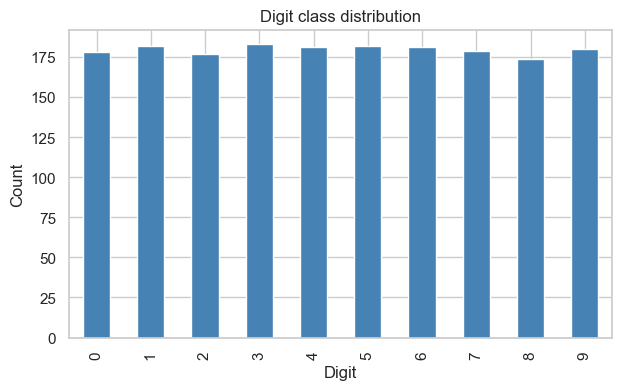

In [19]:
# Class balance
plt.figure(figsize=(7, 4))
pd.Series(y).value_counts().sort_index().plot(kind="bar", color="steelblue")
plt.title("Digit class distribution")
plt.xlabel("Digit")
plt.ylabel("Count")
plt.show()


**Observation:** The 10 digit classes are close to evenly distributed (roughly 174-183 samples each), so accuracy is a fair metric here without needing to worry about class imbalance.

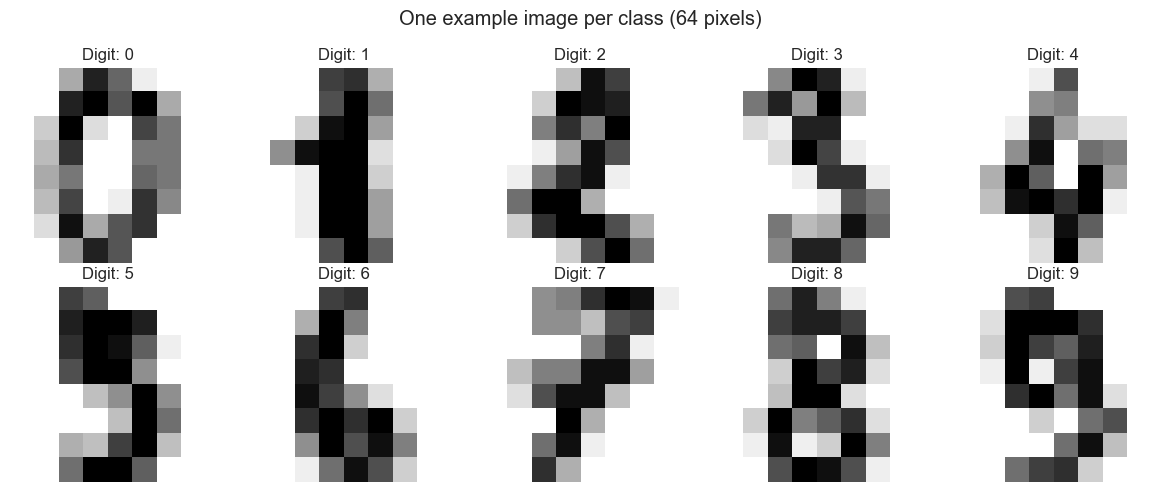

In [27]:
# What the raw data actually looks like: each row is a flattened 8x8 image
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digit in range(10):
    ax = axes[digit // 5, digit % 5]
    sample_image = X[y == digit][0].reshape(8, 8)
    ax.imshow(sample_image, cmap="gray_r")
    ax.set_title(f"Digit: {digit}")
    ax.axis("off") 
plt.suptitle("One example image per class (64 pixels)")
plt.tight_layout() 
plt.show()  

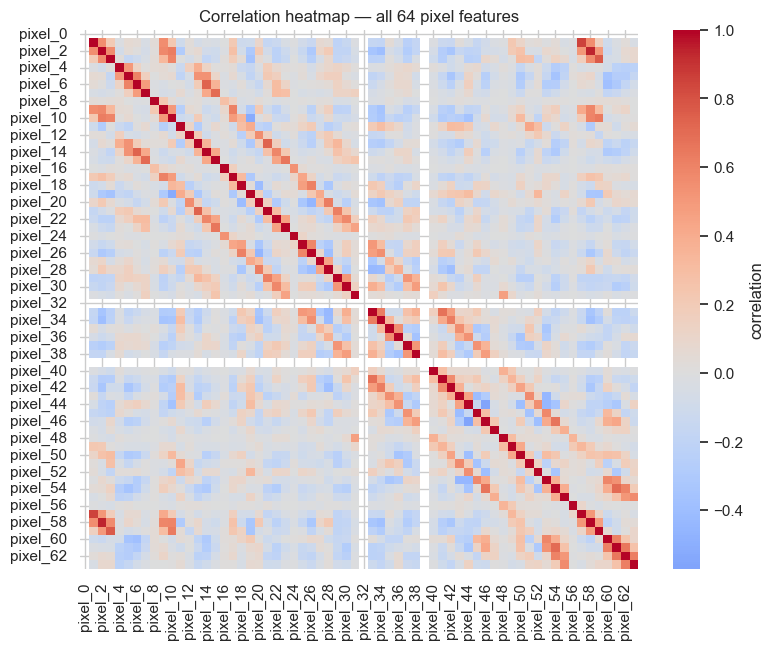

In [28]:
# Correlation between pixel features - lots of redundancy, since neighboring pixels
# tend to be dark/light together, and corner pixels are almost always 0 across all digits
corr = df.drop(columns="label").corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, cmap="coolwarm", center=0, cbar_kws={"label": "correlation"})
plt.title("Correlation heatmap — all 64 pixel features")
plt.show()


**Observation:** Many pixels are correlated with their neighbors (adjacent pixels tend to light up together as part of a stroke), and the corner pixels barely vary at all across samples (they're almost always background/0). This redundancy is exactly what PCA compresses away — this dataset is a clean, visual example of the same idea as the correlation heatmap we saw in the HAR project, just easier to see because we can literally look at the images.

## 2. Baseline Model 

Train/test split first (80/20, stratified by digit so all classes stay balanced in both sets), then a Logistic Regression trained directly on all 64 standardized pixel features. This is the benchmark we compare the PCA-reduced model against in Module 4.